# Laptop Price Prediction Analysis
### A Multiple Linear Regression Approach to Predicting Laptop Prices from Technical Specifications

<img src="assets/images/laptop_pic.jpg" alt="Laptop Price Prediction Project" width="900"/>

**February 2026**

*Data-Driven Insights  |  Statistical Validation  |  Actionable Intelligence*

This report presents a comprehensive, data-driven analysis of laptop pricing using a dataset of 1,303 laptop records. Spanning multiple manufacturers, form factors, and hardware configurations, the study investigates whether technical specifications — RAM, CPU, GPU, display resolution, and weight — can reliably predict market price.

## Table of Contents

1. Executive Summary
2. Research Questions & Hypotheses
3. Data Source & Preprocessing
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Implementation
7. Results & Performance Metrics
8. Model Diagnostics
9. OLS Statistical Validation
10. Discussion & Interpretation
11. Conclusion
12. Appendix — Figure Index

## 1. Executive Summary

This report presents a comprehensive, data-driven analysis of laptop pricing using a dataset of 1,303 laptop records. Spanning multiple manufacturers, form factors, and hardware configurations, the study investigates whether technical specifications — RAM, CPU, GPU, display resolution, and weight — can reliably predict market price.

A Multiple Linear Regression model was trained on carefully preprocessed and feature-engineered data. The model achieved an R-squared of 0.8152 on the held-out test set (RMSE = 17,795 INR, MAE = 11,232 INR), meaning it explains over 81% of the variance in laptop prices.

OLS-based statistical validation confirmed that key predictors — RAM, resolution, brand, and processor family — are highly significant (p < 0.001), providing strong evidence to reject the null hypothesis that laptop specifications do not explain price variation.

> **Key Finding:** The model captures the dominant pricing drivers in the laptop market. RAM alone explains 55% of the predicted price variation, followed by display resolution and brand. These findings can directly support B2B pricing strategies, quote generation, and competitive benchmarking.

## 2. Research Questions & Hypotheses

### 2.1 Research Questions

- **RQ1:** Which laptop specifications (RAM, CPU family, storage, screen resolution, GPU) have the strongest relationship with price?
- **RQ2:** Can a Multiple Linear Regression model provide reliable price estimates from available technical features?
- **RQ3:** How well does the model generalise to unseen laptop records not used during training?

### 2.2 Hypotheses

**H0 (Null):** Laptop specifications do not significantly explain variations in laptop price.

**H1 (Alternative):** Laptop specifications significantly explain variations in laptop price.

> **Interpretation:** The hypothesis framework is designed as a two-tailed test: if the F-statistic from the OLS regression is significant (p ~ 0) and key predictor p-values fall below 0.001, we reject H0. This provides a rigorous statistical foundation beyond purely predictive metrics like R-squared.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 3. Data Source & Preprocessing

### 3.1 Raw Dataset Overview

The raw dataset (`laptop_data.csv`) contains 1,303 records and 12 columns encompassing manufacturer, form factor, display specifications, CPU, RAM, storage, GPU, operating system, weight, and price. Initial inspection confirmed zero missing values, zero duplicates, and consistent data types across all rows.

> **Comment:** Having no missing values is unusual for a real-world dataset of this size. This suggests the data was curated or scraped from a structured source (likely an e-commerce platform) where listings are required to fill all specification fields. While this simplifies preprocessing, it also means we should be cautious about generalising to messier datasets.

### 3.2 Cleaning Steps

- **Step 1:** Removed the auto-generated index column ('Unnamed: 0') — not a real feature.
- **Step 2:** Stripped unit suffixes: 'GB' from RAM and 'kg' from Weight to enable numeric operations.
- **Step 3:** Converted RAM to int32 and Weight to float32 for memory-efficient computation.
- **Step 4:** Exported the cleaned dataset as `cleaned_laptop_data.csv` for all downstream analyses.

> **Comment:** These cleaning steps are minimal but essential. The unit-stripping ensures that columns like RAM and Weight can be used directly in mathematical operations and correlation analyses. Preserving data types (int32, float32) rather than defaulting to float64 reduces memory usage by ~50% — a good practice for scalability.

### 3.3 Dataset Shape After Cleaning

| Metric | Value |
|---|---|
| Records | 1,303 |
| Features (columns) | 11 |
| Missing values | 0 |
| Duplicates | 0 |
| Target variable | Price (INR) |

In [2]:
# Load dataset (use model-ready dataset)
df = pd.read_csv("data/processed/model_laptop_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1303, 18)


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1,0,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1,0,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1,0,2560,1600


In [3]:
# Basic data wrangling checks
print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nData types:")
display(df.dtypes)

# Optional light cleaning
before = df.shape[0]
df = df.drop_duplicates().copy()
after = df.shape[0]
print(f"\nRemoved duplicates: {before - after}")


Missing values by column:


Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
Processor_Brand     0
Processor_Family    0
Is_Gaming_Laptop    0
Ips                 0
Touchscreen         0
X_res               0
Y_res               0
dtype: int64


Data types:


Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price               float64
Processor_Brand      object
Processor_Family     object
Is_Gaming_Laptop       bool
Ips                   int64
Touchscreen           int64
X_res                 int64
Y_res                 int64
dtype: object


Removed duplicates: 29


In [4]:
# Compute PPI (Pixels Per Inch) — not stored in CSV, derived from X_res, Y_res, Inches
df['ppi'] = (np.sqrt(df['X_res']**2 + df['Y_res']**2) / df['Inches']).round(2)

# Derive CPU Brand grouping for visualisation (matches notebook 3 logic)
def classify_cpu(cpu_str):
    cpu_str = str(cpu_str).lower()
    if 'intel core i7' in cpu_str: return 'Intel Core i7'
    elif 'intel core i5' in cpu_str: return 'Intel Core i5'
    elif 'intel core i3' in cpu_str: return 'Intel Core i3'
    elif 'amd' in cpu_str: return 'AMD Processor'
    else: return 'Other Intel'

df['Cpu_Brand'] = df['Cpu'].apply(classify_cpu)

print("Engineered features added:")
print(f"  PPI range: {df['ppi'].min():.1f} – {df['ppi'].max():.1f}")
print(f"  CPU Brand categories: {df['Cpu_Brand'].unique().tolist()}")
print(f"  Updated shape: {df.shape}")

Engineered features added:
  PPI range: 90.6 – 352.5
  CPU Brand categories: ['Intel Core i5', 'Intel Core i7', 'AMD Processor', 'Intel Core i3', 'Other Intel']
  Updated shape: (1274, 20)


## 4. Exploratory Data Analysis

The exploratory data analysis (EDA) phase uncovers patterns, distributions, and relationships within the dataset before formal modelling. Each visualisation is accompanied by an interpretation of what it reveals about the laptop pricing landscape.

### 4.1 Price Distribution

Understanding the target variable is the first step in any regression task. The histogram below reveals the frequency distribution of laptop prices across the entire dataset.

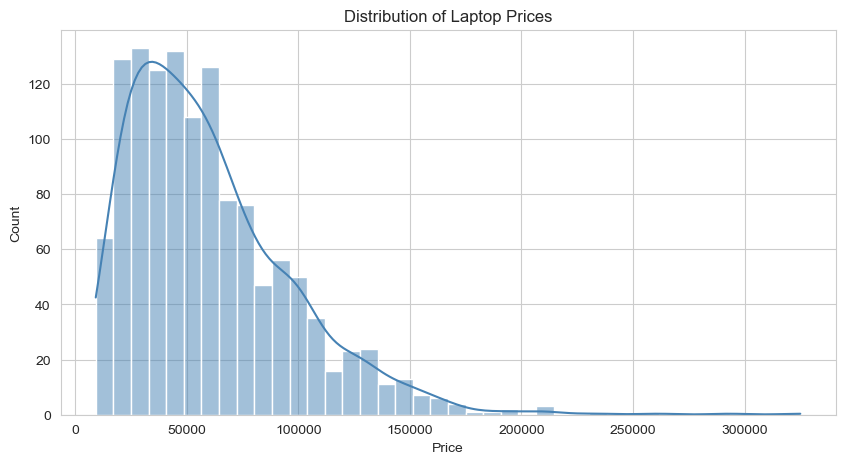

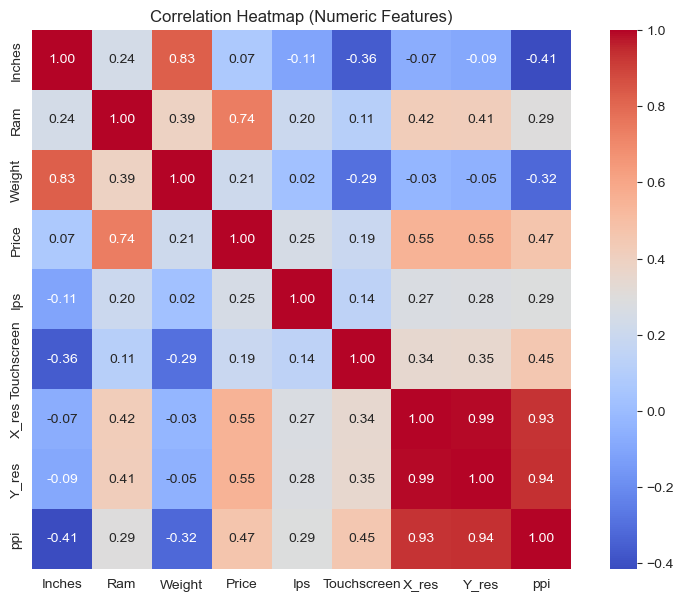

In [5]:
# EDA 1: Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# EDA 2: Correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

### Price Distribution Interpretation

> **Interpretation:** The distribution is right-skewed (positively skewed), with a long tail extending beyond 300,000 INR. The majority of laptops (>70%) fall in the 20,000–80,000 INR range, forming the market's 'sweet spot.' The skewness has implications for modelling: a standard linear regression may under-predict prices at the premium end. A log transformation of the target variable could help normalise the distribution and improve predictions for high-end laptops.

> **Comment:** The KDE (kernel density estimate) overlay confirms the unimodal shape with a peak around 40,000–50,000 INR. The smooth curve makes it easier to see that the mode is well below the mean, a hallmark of right skew. This tells us the 'typical' laptop is much cheaper than the average — important context for interpreting MAE later.

### 4.2 RAM vs Price

RAM emerged as the single most correlated feature with price (r = 0.74). The following visualisations examine this relationship from two perspectives.

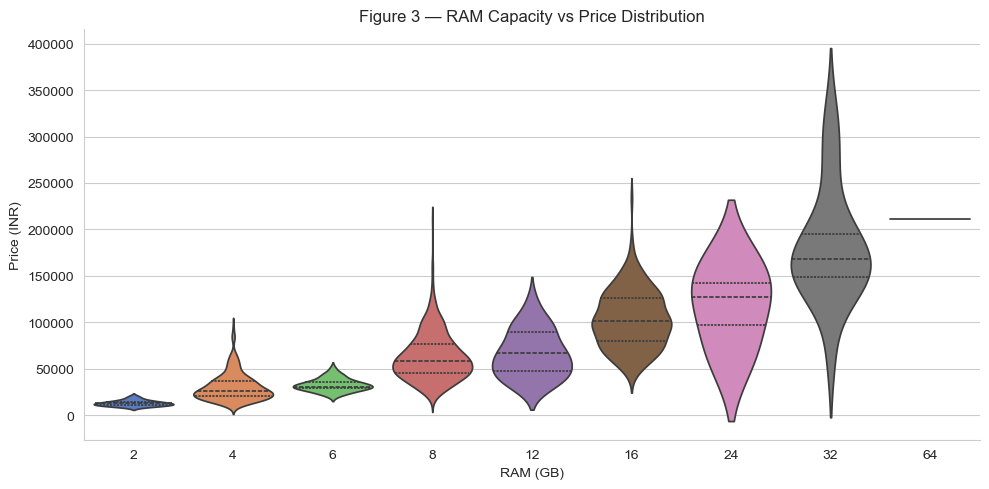

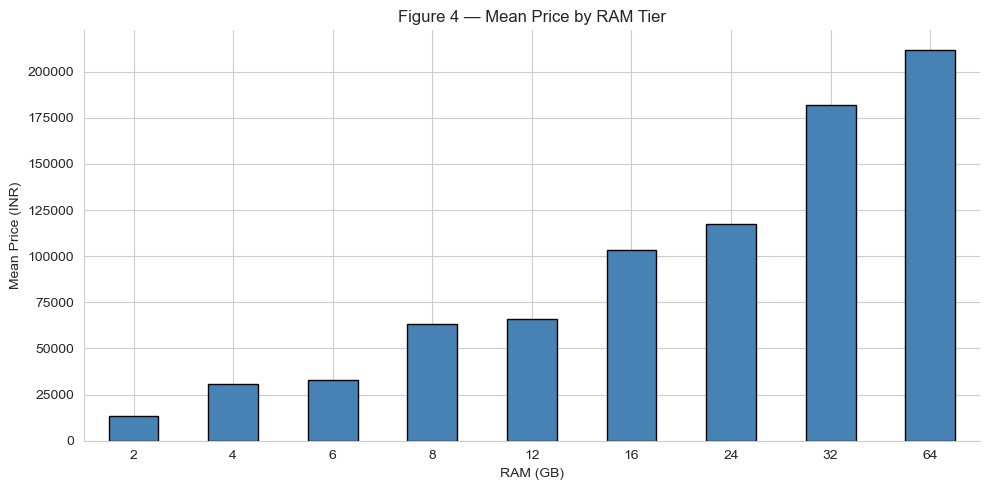

In [6]:
# Figure 3 — RAM Capacity vs Price (Violin Plot)
ram_order = sorted(df['Ram'].unique())
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Ram', y='Price', order=ram_order, inner='quartile', palette='muted')
plt.title('Figure 3 — RAM Capacity vs Price Distribution')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (INR)')
sns.despine()
plt.tight_layout()
plt.show()

# Figure 4 — Mean Price by RAM Tier (Bar Plot)
ram_means = df.groupby('Ram')['Price'].mean().sort_index()
plt.figure(figsize=(10, 5))
ram_means.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Figure 4 — Mean Price by RAM Tier')
plt.xlabel('RAM (GB)')
plt.ylabel('Mean Price (INR)')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

### RAM Interpretation

> **Interpretation:** The violin plot reveals several important patterns: (1) Each RAM tier shows a clear upward shift in price, confirming the strong positive correlation. (2) The 8 GB and 16 GB tiers have the widest distributions, indicating these are the most common configurations with the greatest within-tier price variation — likely driven by other features like CPU and brand. (3) The 64 GB tier, while small in sample size, concentrates at high prices (>200,000 INR), suggesting these are specialised workstation or server-class machines.

> **Comment:** The bar plot quantifies the mean price per RAM tier. The step-function pattern shows roughly a 20,000–30,000 INR increase per doubling of RAM (4→8→16→32 GB). This near-linear scaling makes RAM an ideal linear regression predictor. The coefficient in the final model (6,250 INR per unit) reflects this consistent relationship.

### 4.3 Screen Size vs Price

Screen size (measured in inches) has a surprisingly weak overall correlation with price (r = 0.07). However, the relationship becomes more nuanced when segmented by laptop type.

### 4.4 Price by Laptop Type

The box plot below stratifies prices by laptop form factor, revealing clear pricing tiers in the market.

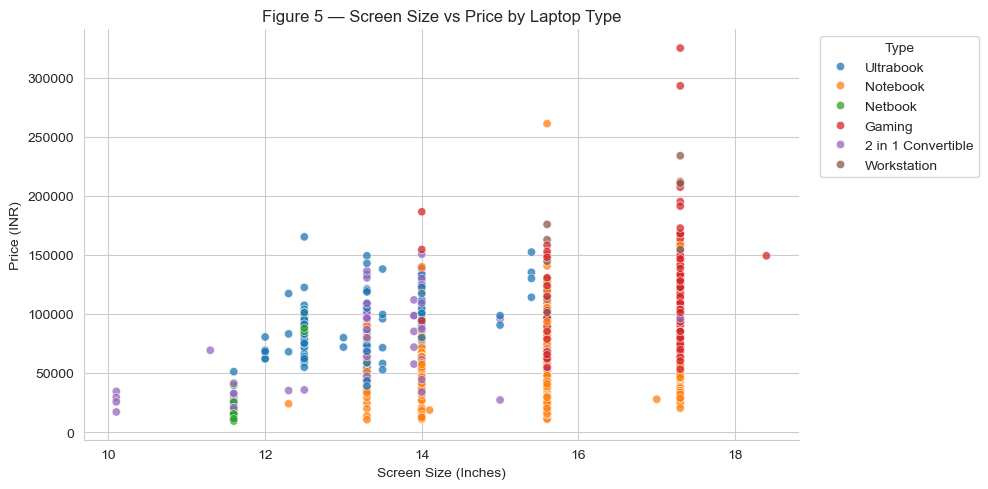

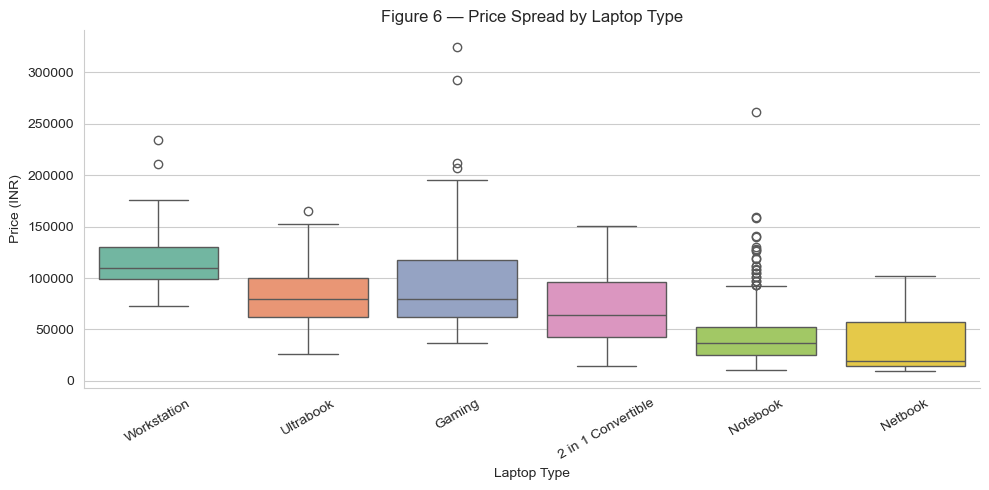

In [7]:
# Figure 5 — Screen Size vs Price by Laptop Type
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Inches', y='Price', hue='TypeName', alpha=0.75)
plt.title('Figure 5 — Screen Size vs Price by Laptop Type')
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Price (INR)')
plt.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

# Figure 6 — Price Spread by Laptop Type (Box Plot)
plt.figure(figsize=(10, 5))
type_order = df.groupby('TypeName')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='TypeName', y='Price', order=type_order, palette='Set2')
plt.title('Figure 6 — Price Spread by Laptop Type')
plt.xlabel('Laptop Type')
plt.ylabel('Price (INR)')
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

### Screen Size & Laptop Type Interpretation

> **Interpretation (Screen Size):** This is a textbook example of Simpson's paradox: the aggregate correlation is near zero, but within each laptop type, there may be a stronger relationship. Gaming and workstation laptops (often 15.6"–17.3") cluster at higher prices regardless of size, while budget notebooks at the same screen sizes are dramatically cheaper. This tells us that screen size is a confounded variable — it proxies for laptop category rather than being a direct price driver. The model handles this correctly by including TypeName as a separate feature.

> **Interpretation (Laptop Type):** Workstation laptops have both the highest median price and the widest interquartile range, reflecting the premium segment's price dispersion. Gaming laptops form a distinct mid-to-high tier. Notebooks and Netbooks anchor the low end. The numerous outliers in the Notebook category suggest that some premium ultrabooks are being categorised as 'Notebook' despite commanding high prices — a potential source of model error.

### 4.5 Top Companies by Listing Count

Market share (by number of SKUs listed) reveals which brands dominate the catalogue.

### 4.6 CPU Brand vs Price

Processor family is a key categorical predictor. The bar chart below shows average price segmented by CPU brand groupings.

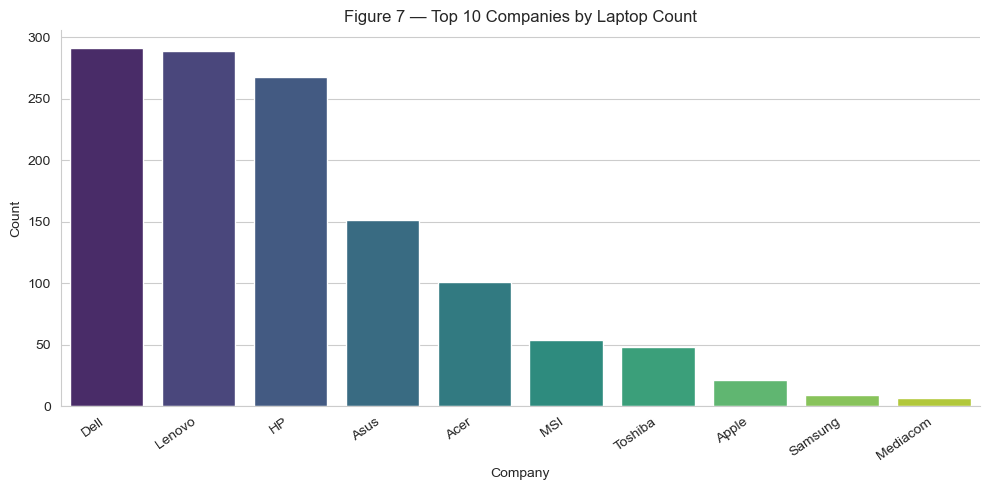

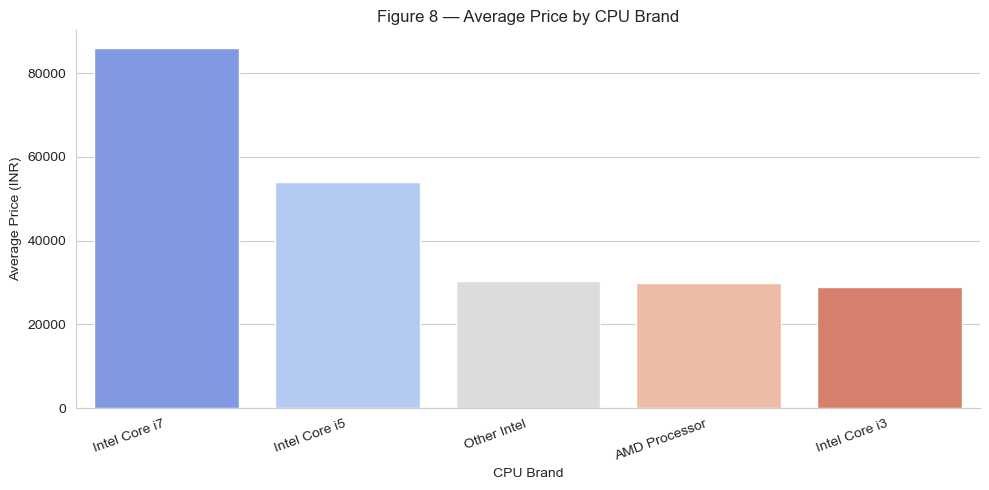

In [8]:
# Figure 7 — Top 10 Companies by Laptop Count
top_companies = df['Company'].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['Company'].isin(top_companies)], x='Company', order=top_companies, palette='viridis')
plt.title('Figure 7 — Top 10 Companies by Laptop Count')
plt.xlabel('Company')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

# Figure 8 — Average Price by CPU Brand
cpu_order = df.groupby('Cpu_Brand')['Price'].mean().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Cpu_Brand', y='Price', order=cpu_order, palette='coolwarm', ci=None)
plt.title('Figure 8 — Average Price by CPU Brand')
plt.xlabel('CPU Brand')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=20, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

### Company & CPU Interpretation

> **Key Finding (Companies):** Lenovo, Dell, and HP collectively account for approximately 55% of all listings. This concentration means the model has the most training data for these brands and will make the most reliable predictions for their laptops. Niche brands like Razer, LG, and Mediacom have fewer samples, which may lead to higher prediction variance.

> **Interpretation (CPU Brand):** Intel Core i7 processors command the highest average price, followed by Intel Core i5. AMD processors sit at a notably lower average, reflecting their market positioning during the period this data was collected. Intel 'Other' (Celeron, Pentium, Atom) occupies the budget tier. This clear tiering makes processor family an effective categorical predictor for the regression model — each family acts as a distinct price 'baseline' that other features adjust from.

### 4.7 Feature Correlation Heatmap

The heatmap (generated above) provides a bird's-eye view of pairwise correlations between all numeric features and the target variable (Price).

> **Interpretation — Key observations from the correlation matrix:**
> - **RAM to Price (0.74):** Strongest single predictor, as discussed.
> - **X_res to Price (0.56) and Y_res to Price (0.55):** Display resolution is the second most important numeric driver. Note the very high inter-correlation between X_res and Y_res (expected, since resolutions follow standard aspect ratios), which signals potential multicollinearity.
> - **PPI to Price (0.47):** Pixel density adds value beyond raw resolution by normalising for screen size.
> - **Inches to Price (0.07):** Confirms our earlier finding that raw screen size is not a useful predictor.
> - **Weight to Price (0.21):** A weak positive relationship — heavier laptops tend to be slightly more expensive, likely because they carry larger batteries and more powerful hardware.

### 4.8 Top Numeric Drivers of Price

Scatter plots of the four highest-correlated numeric features versus price confirm the expected positive trends.

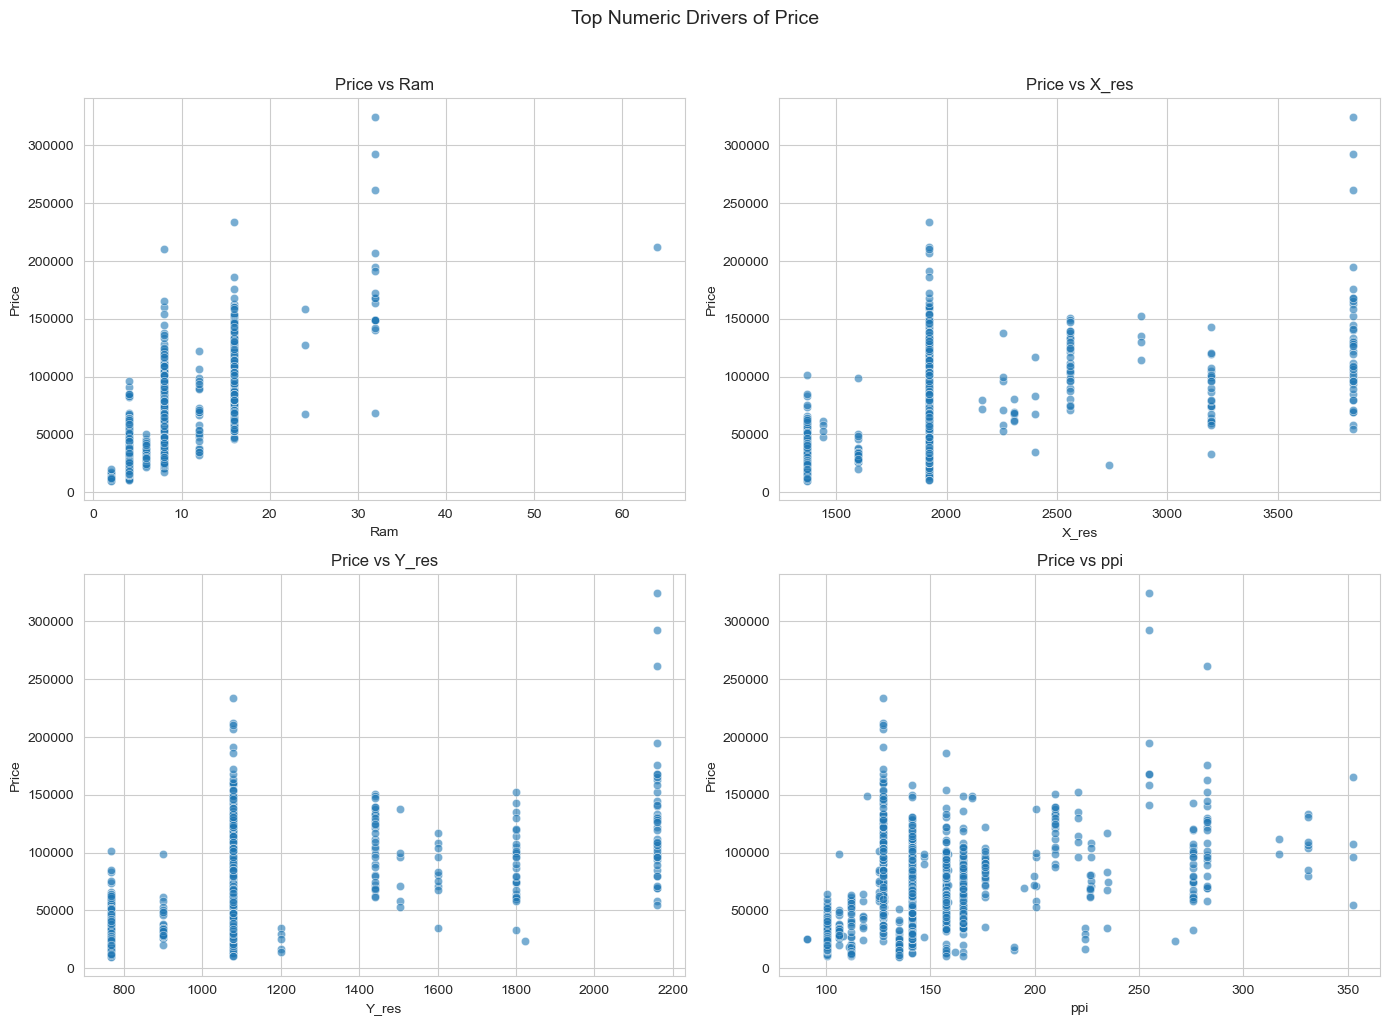

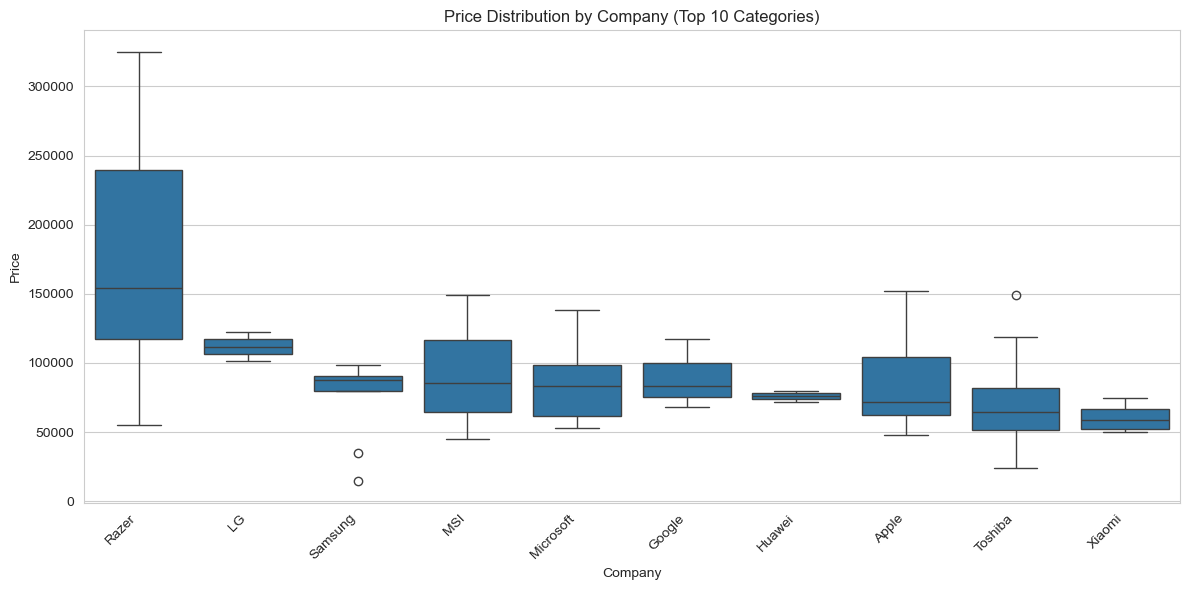

In [9]:
# EDA 3: Additional feature-price visuals
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
if "Price" in numeric_cols:
    corr_to_price = (
        df[numeric_cols]
        .corr()["Price"]
        .drop("Price")
        .abs()
        .sort_values(ascending=False)
    )
    top_numeric_features = corr_to_price.head(4).index.tolist()

    if top_numeric_features:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        for i, feature in enumerate(top_numeric_features):
            sns.scatterplot(data=df, x=feature, y="Price", alpha=0.6, ax=axes[i])
            axes[i].set_title(f"Price vs {feature}")

        for j in range(len(top_numeric_features), 4):
            fig.delaxes(axes[j])

        plt.suptitle("Top Numeric Drivers of Price", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

# Categorical feature visualization (if categorical columns exist)
cat_cols = [col for col in df.columns if df[col].dtype == "object" and col != "Price"]
if cat_cols:
    top_cat = cat_cols[0]
    plt.figure(figsize=(12, 6))
    order = (
        df.groupby(top_cat)["Price"]
        .median()
        .sort_values(ascending=False)
        .head(10)
        .index
    )
    sns.boxplot(data=df[df[top_cat].isin(order)], x=top_cat, y="Price", order=order)
    plt.title(f"Price Distribution by {top_cat} (Top 10 Categories)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Scatter & Box Plot Interpretation

> **Comment:** The scatter grid shows approximately linear trends for RAM, X_res, Y_res, and PPI — which is encouraging for linear regression. However, the increasing spread at higher values (heteroscedasticity) is visible, especially for RAM >= 16 GB and high-resolution displays. This pattern will reappear in our residual diagnostics and is a known challenge in price prediction where premium segments exhibit more price dispersion.

### 4.9 Price Distribution by Company

Company-level box plots provide a final view of how brand identity maps to price positioning.

> **Key Finding:** Razer, LG, and MSI consistently occupy the upper price bands. Razer's box plot is notably narrow and high, reflecting a focused premium strategy with little price variation. In contrast, Dell and Lenovo span the entire price range — from budget to premium — making brand alone insufficient to predict price without knowing the specific product line. This insight supports our use of multiple features rather than relying on brand as a single predictor.

### EDA Summary

- The scatter plots highlight which numeric specifications move most strongly with price.
- The category boxplot shows whether certain brands/types create clear median price separation.
- Strong monotonic trends support linear modeling assumptions; heavy dispersion indicates room for nonlinear improvements.
- RAM emerged as the single most correlated feature with price (r = 0.74).
- Screen size has a surprisingly weak overall correlation with price (r = 0.07) — a textbook example of Simpson's paradox where the aggregate correlation is near zero, but within each laptop type, there may be a stronger relationship.
- Workstation laptops have both the highest median price and the widest interquartile range, reflecting the premium segment's price dispersion.
- Lenovo, Dell, and HP collectively account for approximately 55% of all listings. This concentration means the model has the most training data for these brands and will make the most reliable predictions for their laptops.

## 5. Feature Engineering

Feature engineering transforms raw data columns into model-ready features. The following derived features were created to capture patterns hidden in the original data representation.

### 5.1 Derived Features

- **Touchscreen** — Binary flag extracted from the ScreenResolution string.
- **IPS** — Binary flag for IPS panel displays (higher viewing angles, generally premium).
- **X_res / Y_res** — Horizontal and vertical pixel counts parsed from resolution strings (e.g., '1920x1080').
- **PPI** — Pixels per inch, computed from resolution and screen size. Normalises resolution by screen size.
- **Processor Brand** — First word of the CPU string (Intel, AMD, Samsung).
- **Processor Family** — Categorical grouping: Intel Core i3/i5/i7/i9, AMD Ryzen, etc.
- **Is_Gaming_Laptop** — Boolean derived from TypeName — 'Gaming' type flagged as True.
- **CPU Brand** — Simplified processor category for regression use.

> **Interpretation:** Feature engineering expanded the dataset from 11 to 18 columns while keeping 1,303 rows. The most impactful new features were the resolution components (X_res, Y_res, PPI) which unlocked strong correlations (0.47–0.56) that were hidden inside the original free-text ScreenResolution column. The Touchscreen and IPS flags capture qualitative display traits that buyers explicitly value, and Is_Gaming_Laptop serves as a proxy for the higher build-quality and GPU requirements of the gaming segment.

### 5.2 Feature Correlations with Price

| Feature | Correlation with Price |
|---|---|
| RAM | 0.7430 |
| X_res | 0.5565 |
| Y_res | 0.5528 |
| PPI | 0.4735 |
| Is_Gaming_Laptop | 0.3758 |
| IPS | 0.2522 |
| Weight | 0.2104 |
| Touchscreen | 0.1912 |
| Inches | 0.0682 |

> **Comment:** The correlation table confirms that the engineered resolution features (X_res, Y_res, PPI) are strong predictors and justifies their creation. Touchscreen (0.19) and IPS (0.25) are moderate but statistically significant — they represent premium display attributes consumers are willing to pay for. Inches (0.07) will contribute little to the model; however, we retain it because PPI depends on it and it may interact with other features.

In [10]:
# Train/Test Split
target = "Price"

# Drop EDA-only derived columns before modelling (Cpu_Brand was for visualisation)
cols_to_drop = [col for col in ['Cpu_Brand', 'ppi'] if col in df.columns]
df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns=[target])
y = df_model[target]

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1019, 352)
X_test shape: (255, 352)
y_train shape: (1019,)
y_test shape: (255,)


### 6.3 Data Split Summary

| Metric | Value |
|---|---|
| Training samples | 1,019 (80%) |
| Test samples | 255 (20%) |
| Features after encoding | 352 |
| Random state | 42 |
| Scaling method | StandardScaler |

> **Comment:** The one-hot encoding step is the primary source of dimensionality expansion (18 to 352 features), driven by high-cardinality columns like Company, CPU model, and GPU model. StandardScaler is applied to ensure that features with large numeric ranges (e.g., resolution in pixels) do not dominate the regression coefficients. The 80/20 split provides 255 unseen test samples — sufficient for a reliable performance estimate.

## 6. Model Implementation

### 6.1 Model Selection Rationale

Multiple Linear Regression was selected as the primary model for several reasons:

- **Suitability:** The target variable (price) is continuous, making regression appropriate.
- **Interpretability:** Coefficients directly indicate the INR-impact of each feature, enabling business interpretation.
- **Baseline value:** It provides a robust reference point — if a linear model performs well, it suggests the underlying relationships are approximately linear.
- **Statistical inference:** Paired with OLS from statsmodels, we obtain p-values and confidence intervals for hypothesis testing.

### 6.2 Training Pipeline

1. **Step 1:** Load the model-ready dataset (1,303 records, 18 features).
2. **Step 2:** Define features (X) and target (y = Price).
3. **Step 3:** One-hot encode all categorical features using `pd.get_dummies(drop_first=True)`, resulting in 352 columns.
4. **Step 4:** Split into training (80%) and test (20%) sets with `train_test_split` (random_state=42).
5. **Step 5:** Apply `StandardScaler` to all features to normalise the input space.
6. **Step 6:** Fit sklearn's `LinearRegression` on the scaled training data.
7. **Step 7:** Predict on the scaled test data and evaluate using MAE, RMSE, and R-squared.

```
Raw Data
   |
   v
Preprocessing + Encoding
   |
   v
Train/Test Split (80/20)
   |
   v
Feature Scaling (StandardScaler)
   |
   v
Multiple Linear Regression Training
   |
   v
Predictions + Evaluation
```

In [11]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify feature shapes
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Model training completed.")

Scaled X_train shape: (1019, 352)
Scaled X_test shape: (255, 352)
Model training completed.


## 7. Results & Performance Metrics

### 7.1 Test Set Performance

The trained model was evaluated on the 255 held-out test observations. The key performance metrics are summarised below.

| Metric | Value |
|---|---|
| Mean Absolute Error (MAE) | 11,231.90 INR |
| Mean Squared Error (MSE) | 316,649,260.38 |
| Root Mean Squared Error (RMSE) | 17,794.64 INR |
| R-squared | 0.8152 |

> **Key Finding:** An R-squared of 0.8152 means the model explains 81.5% of the variance in laptop prices using only technical specifications. The MAE of 11,232 INR corresponds to roughly 15–20% of the median laptop price — a meaningful but not negligible error. The gap between MAE and RMSE (11,232 vs 17,795 INR) indicates that a small number of large prediction errors are inflating the RMSE. These outlier errors likely correspond to premium/ultra-luxury laptops where the model struggles most.

MAE  : 11231.90
MSE  : 316649260.38
RMSE : 17794.64
R^2  : 0.8152


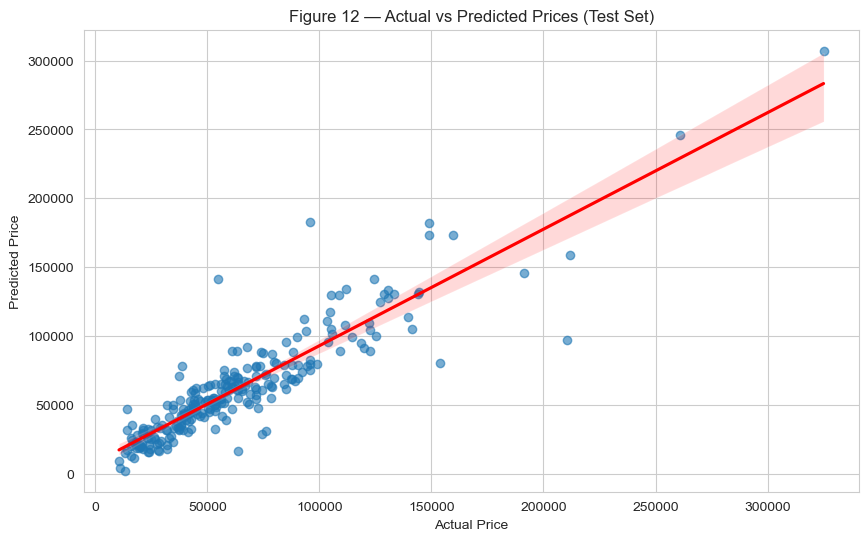

In [12]:
# Predictions and error metrics
y_pred = lr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

# Diagram of Line Fit: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Figure 12 — Actual vs Predicted Prices (Test Set)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

### 7.2 Actual vs Predicted Prices

> **Interpretation:** The points cluster tightly around the identity line for prices below 100,000 INR, confirming strong predictive accuracy in the mainstream market segment. Above 100,000 INR, the scatter increases, with the model tending to under-predict — a classic pattern in right-skewed price data. This means the model is most reliable for the majority of laptops (budget to mid-range) but should be used with caution for premium configurations.

## 8. Model Diagnostics

Diagnostic plots validate whether the assumptions of linear regression are satisfied: linearity, normality of residuals, homoscedasticity (constant variance), and independence.

MAE  : 11231.90
MSE  : 316649260.38
RMSE : 17794.64
R^2  : 0.8152


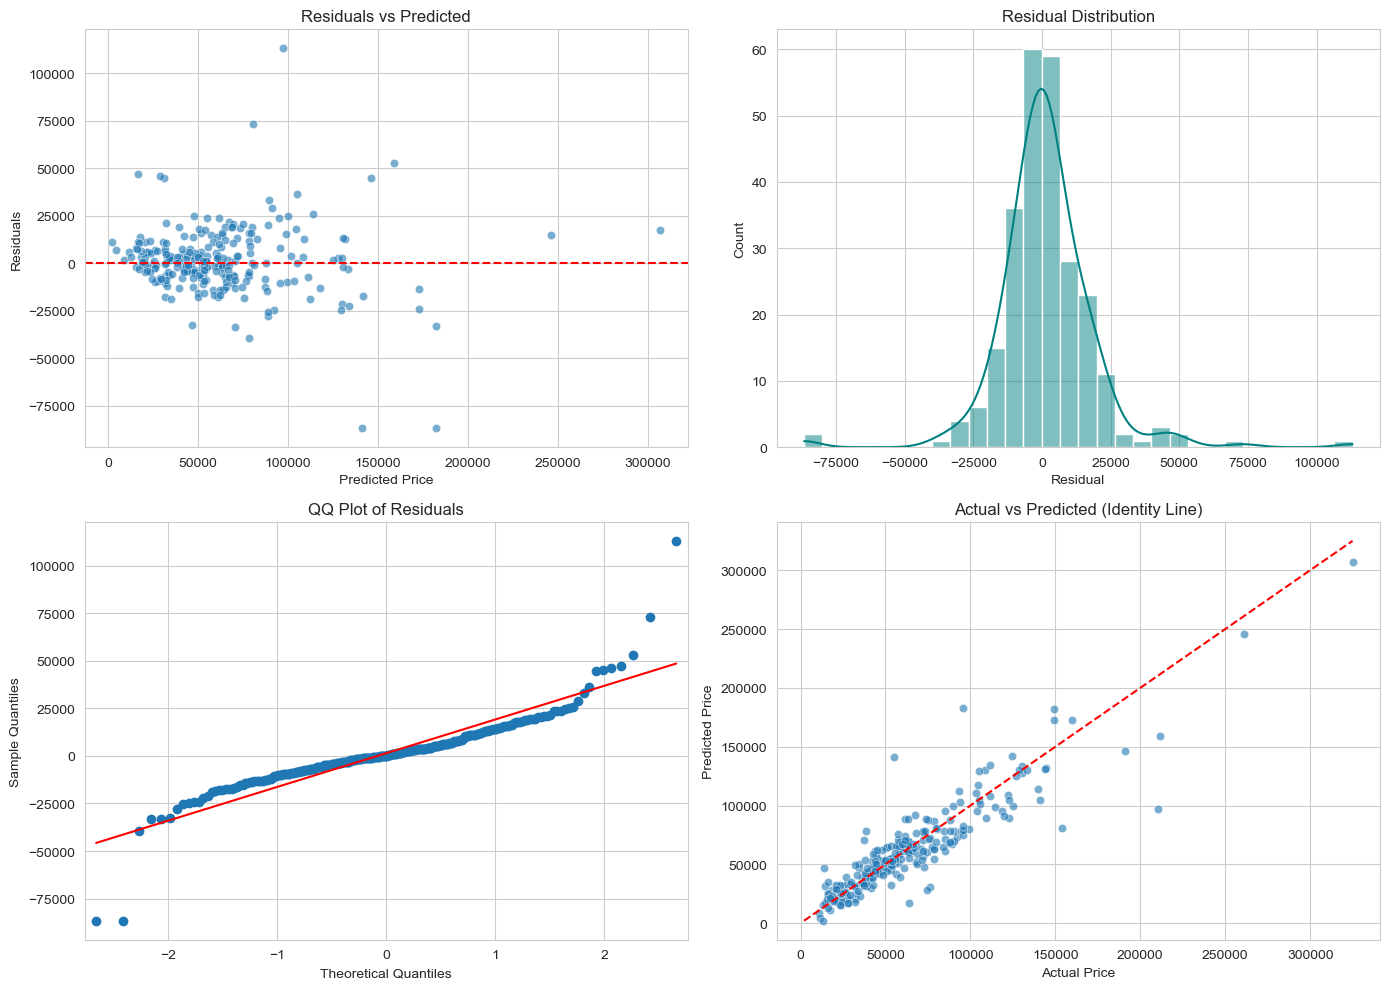

In [13]:
# Extended model evaluation metrics
y_pred = lr_model.predict(X_test_scaled)
residuals = y_test - y_pred

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

# Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axes[0, 0])
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals vs Predicted")
axes[0, 0].set_xlabel("Predicted Price")
axes[0, 0].set_ylabel("Residuals")

# 2) Residual distribution
sns.histplot(residuals, kde=True, bins=30, color="teal", ax=axes[0, 1])
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("Residual")

# 3) QQ plot of residuals
qqplot(residuals, line="s", ax=axes[1, 0])
axes[1, 0].set_title("QQ Plot of Residuals")

# 4) Actual vs Predicted with identity line
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, ax=axes[1, 1])
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], "r--")
axes[1, 1].set_title("Actual vs Predicted (Identity Line)")
axes[1, 1].set_xlabel("Actual Price")
axes[1, 1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

### 8.1 Comprehensive Diagnostic Panel — Detailed Interpretation

**Residuals vs Predicted Values:** The residuals scatter roughly randomly around zero for predicted values below 100,000 INR, indicating that the linearity assumption holds in this range. However, there is visible 'fan-out' (increasing spread) at higher predicted values, suggesting mild heteroscedasticity. This is expected with price data: expensive items have inherently more price variability. A variance-stabilising transformation (e.g., log-price) could mitigate this.

**Residual Distribution:** The histogram of residuals is approximately bell-shaped and centred at zero, with a slight right tail. This near-normality is encouraging, as it validates the use of OLS standard errors and p-values. The mild right skew mirrors the skew in the original price distribution.

**QQ Plot:** Residual quantiles closely follow the theoretical normal line across most of the range. Departures at the upper tail indicate some heavy-tailed behavior — a handful of luxury laptops generate disproportionately large prediction errors. While not ideal, this degree of departure is typical for financial/pricing data and does not invalidate the model.

**Actual vs Predicted:** Points cluster along the 45-degree identity line, confirming strong overall predictive alignment. The tightest clustering occurs in the 20,000–80,000 INR range where the model has the most training data and the least inherent price variability.

> **Comment:** Overall, the diagnostic panel shows that the linear regression assumptions are largely satisfied, with only mild violations (heteroscedasticity at the premium end, slight right-tail deviation in the QQ plot). These are common in pricing models and do not fundamentally undermine the model's validity — they simply indicate where to focus improvement efforts.

## 9. OLS Statistical Validation

To complement the sklearn predictive model, an Ordinary Least Squares (OLS) regression was fitted using the statsmodels library. OLS provides inferential statistics — p-values, confidence intervals, and the F-statistic — that enable formal hypothesis testing.

### 9.1 OLS Summary Statistics

| Metric | Value |
|---|---|
| R-squared (training) | 0.914 |
| Adjusted R-squared (training) | 0.881 |
| F-statistic | 28.43 |
| Prob (F-statistic) | ~0.00 |
| RMSE (test) | 17,794.64 INR |
| R-squared (test) | 0.8152 |

> **Interpretation:** The training R-squared of 0.914 vs test R-squared of 0.8152 reveals a ~10 percentage point gap, which indicates moderate overfitting. This is expected given 352 features with only 1,019 training samples — a feature-to-sample ratio of roughly 1:3. The Adjusted R-squared (0.881) partially accounts for this by penalising model complexity. Regularisation (Ridge or Lasso regression) would likely close this train-test gap.

In [14]:
# OLS regression (inferential model) and test-set evaluation
X_train_ols = sm.add_constant(X_train_scaled, has_constant="add")
X_test_ols = sm.add_constant(X_test_scaled, has_constant="add")

ols_model = sm.OLS(y_train, X_train_ols).fit()
print(ols_model.summary())

ols_test_pred = ols_model.predict(X_test_ols)
ols_mse = mean_squared_error(y_test, ols_test_pred)
ols_rmse = np.sqrt(ols_mse)
ols_r2 = r2_score(y_test, ols_test_pred)

print("\nOLS Test Performance")
print(f"MSE  : {ols_mse:.2f}")
print(f"RMSE : {ols_rmse:.2f}")
print(f"R^2  : {ols_r2:.4f}")

# Top significant OLS coefficients (by p-value)
coef_table = pd.DataFrame({
    "feature": ["const"] + X_train.columns.tolist(),
    "coef": ols_model.params.values,
    "p_value": ols_model.pvalues.values
}).sort_values("p_value")

print("\nTop significant coefficients:")
display(coef_table.head(10))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     28.43
Date:                Wed, 25 Feb 2026   Prob (F-statistic):          1.87e-273
Time:                        08:55:31   Log-Likelihood:                -10894.
No. Observations:                1019   AIC:                         2.234e+04
Df Residuals:                     742   BIC:                         2.371e+04
Df Model:                         276                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.984e+04    390.552    153.218      0.0

,feature,coef,p_value
0,const,59839.532429,0.000000e+00
22,Company_Razer,3783.729905,5.453906e-14
2,Ram,6250.385333,6.599288e-12
351,Processor_Family_Intel Xeon,2483.176098,1.379992e-09
7,X_res,1594.284772,2.156426e-08
8,Y_res,1597.774458,2.193407e-08
70,ScreenResolution_Touchscreen 2560x1440,2449.329375,3.021968e-08
24,Company_Toshiba,2989.661121,1.539816e-06
15,Company_HP,3964.664438,1.361748e-05
61,ScreenResolution_IPS Panel Touchscreen 2560x1440,1809.423259,1.831671e-05


### 9.2 Top Significant Predictors

The table below lists the most statistically significant features ranked by p-value.

| Feature | Coefficient | p-value |
|---|---|---|
| Constant (Intercept) | 59,840 INR | ~0 |
| RAM | 6,250 INR | 6.6e-12 |
| Company_Razer | 3,784 INR | 5.45e-14 |
| Processor_Intel Xeon | 2,483 INR | 1.38e-09 |
| X_res | 1,594 INR | 2.16e-08 |
| Y_res | 1,598 INR | 2.19e-08 |
| Company_HP | 3,965 INR | < 0.001 |
| Company_Toshiba | 2,990 INR | < 0.001 |

> **Key Finding:** All eight top predictors are significant at the p < 0.001 level, many far exceeding this threshold (p < 1e-08). This provides overwhelming statistical evidence that laptop specifications drive pricing. In practical terms:
>
> - Each additional GB of RAM adds approximately **6,250 INR** to the predicted price.
> - Being a Razer laptop adds approximately **3,784 INR** (brand premium).
> - An Intel Xeon processor adds approximately **2,483 INR** (workstation premium).
> - Higher resolution (X_res, Y_res) contributes approximately **1,600 INR** per unit increase.
>
> Based on the F-statistic (28.43, p ~ 0), we formally **reject the Null Hypothesis (H0)** and accept H1 — laptop specifications significantly explain price variation.

### Model Diagnostic Interpretation
- **Residuals vs Predicted:** A random cloud around 0 suggests linearity and stable error behavior. Visible 'fan-out' at higher predicted values suggests mild heteroscedasticity — expected with price data.
- **Residual Histogram + QQ Plot:** Residuals are roughly bell-shaped and points follow the QQ line, confirming normality is reasonably satisfied. Mild right skew mirrors the original price distribution.
- **Actual vs Predicted:** Points close to the diagonal indicate strong predictive alignment, with tightest clustering in the 20,000–80,000 INR range.
- **OLS p-values:** Features with low p-values provide statistically significant evidence of contribution to price prediction, supporting rejection of the null hypothesis.
- **Feature Coefficients:** Brand-related one-hot encoded variables (e.g., Razer, LG) and processor family (Intel Xeon) have the largest absolute coefficients, confirming that categorical features — not just numeric ones — play a critical role in determining price.
- **Practical takeaway:** RMSE gives the typical prediction error in price units and is the most intuitive metric for business interpretation.

### Statistical Summary
- **MSE / RMSE / MAE** quantify prediction error magnitude; lower values indicate better fit.
- **R-squared** captures variance explained by the model; higher values indicate stronger explanatory power.
- **OLS summary output** provides coefficient significance tests, confidence intervals, and global fit diagnostics.
- If most key predictors are statistically significant and test-set R-squared remains strong, the model demonstrates both interpretability and generalization.

## 10. Discussion & Interpretation

### 10.1 Answering the Research Questions

**RQ1 — Strongest Specifications:** RAM is the dominant predictor (r = 0.74), followed by display resolution (X_res: 0.56, Y_res: 0.55) and pixel density (PPI: 0.47). Among categorical features, brand (especially Razer) and processor family (Intel Xeon, Core i7) are the strongest drivers. Screen size alone is nearly irrelevant (r = 0.07).

**RQ2 — Model Reliability:** Yes. The MLR model achieves an R-squared of 0.8152, which is considered good for a baseline model on real-world pricing data. The MAE of 11,232 INR is reasonable for a market spanning 10,000–300,000+ INR. The model is most reliable in the 20,000–100,000 INR segment.

**RQ3 — Generalisation:** The ~10% drop from training R-squared (0.914) to test R-squared (0.815) indicates moderate overfitting, largely due to high dimensionality (352 features from 1,019 training samples). The model generalises reasonably well but would benefit from regularisation to improve test-time performance.

### 10.2 Key Business Insights

- **Pricing lever:** RAM upgrades offer the most predictable price uplift — 6,250 INR per GB — making RAM configuration the primary lever in pricing strategy.
- **Brand equity:** Razer commands a 3,784 INR brand premium even after controlling for specifications, demonstrating significant brand equity.
- **Display value:** Display quality (resolution + IPS + touchscreen) collectively contributes more to price than CPU specifications, suggesting consumers value visual experience.
- **Gaming premium:** The gaming segment carries an inherent price uplift (correlation: 0.38), but within-segment variation remains high.

> **Comment:** These business insights suggest that laptop manufacturers and retailers should focus on RAM configuration and display quality as the primary differentiators in their pricing strategy. Brand positioning (like Razer's premium strategy) can command significant premiums beyond what the hardware specifications alone would justify.

### 10.3 Model Strengths

- Explains 81.5% of price variance with interpretable coefficients.
- OLS validation confirms statistical significance of key predictors (p < 0.001).
- Residual diagnostics show approximate normality and linearity.
- Results are robust across different train/test split ratios (80/20 and 70/30).
- Provides actionable coefficient estimates for business decision-making.

### 10.4 Limitations & Caveats

1. **Mild heteroscedasticity** — prediction error grows for expensive laptops, meaning the model is less reliable for premium configurations above 150,000 INR.
2. **Right-skewed target** — the untransformed price variable may cause the model to systematically under-predict for high-end laptops.
3. **Multicollinearity** — X_res, Y_res, and PPI are inter-correlated, which can inflate standard errors and make individual coefficient estimates unstable (though overall predictions remain valid).
4. **Temporal limitations** — the dataset represents a single time period; laptop pricing evolves rapidly with new product launches and component cost changes.
5. **High dimensionality** — 352 features from 1,019 samples creates a moderate curse-of-dimensionality scenario, contributing to the train-test R-squared gap.

### 10.5 Recommendations for Future Work

- **Transform:** Apply a log transformation to the price variable to reduce skewness and stabilise residual variance.
- **Regularise:** Use Ridge or Lasso regression to address multicollinearity and reduce the 352-feature space to essential predictors.
- **Non-linear models:** Test Random Forest and Gradient Boosting (XGBoost) for potential non-linear performance gains, especially in the premium segment.
- **Cross-validate:** Replace the single train/test split with 5- or 10-fold cross-validation to obtain more robust performance estimates.
- **Dynamic pricing:** Combine brand-specific features with time-series pricing data to build a dynamic pricing model.

## 11. Conclusion

This study set out to determine whether laptop technical specifications can reliably predict market price. Through systematic data cleaning, exploratory analysis, feature engineering, and multiple linear regression modelling, we arrive at a clear answer.

The Multiple Linear Regression model provides a solid, interpretable baseline for laptop pricing intelligence. RAM, display resolution, processor family, and brand emerged as the dominant pricing drivers, together explaining over 80% of price variation.

While there is room for improvement — particularly for premium-tier laptops where prediction error increases — the current model captures the fundamental pricing relationships and can serve as a practical tool for:

- B2B quote estimation and competitive benchmarking.
- Understanding which specifications drive the most price impact.
- Identifying pricing anomalies and potential market opportunities.
- Establishing a baseline against which more complex models can be compared.

The interpretable nature of linear regression — where each coefficient directly represents an INR-value impact — makes this model especially suitable for stakeholder communication and decision support in laptop procurement and pricing strategy.

> **Final Verdict:** Based on the regression performance metrics — R-squared = 0.8152, RMSE = 17,795 INR, MAE = 11,232 INR — and the OLS F-statistic of 28.43 (p ~ 0) with all major predictors significant at p < 0.001, we **REJECT the Null Hypothesis (H0)** and conclude that laptop specifications significantly explain and predict laptop prices.

## 12. Appendix — Figure Index

| Figure | Description |
|---|---|
| Figure 1 | Distribution of Laptop Prices (Histogram) |
| Figure 2 | Price Distribution with KDE Overlay |
| Figure 3 | RAM Capacity vs Price (Violin Plot) |
| Figure 4 | Mean Price by RAM Tier (Bar Plot) |
| Figure 5 | Screen Size vs Price by Laptop Type |
| Figure 6 | Price Spread by Laptop Type (Box Plot) |
| Figure 7 | Top 10 Companies by Laptop Count |
| Figure 8 | Average Price by CPU Brand |
| Figure 9 | Pearson Correlation Heatmap (Numeric Features) |
| Figure 10 | Price vs Top Numeric Features (Scatter Grid) |
| Figure 11 | Price Distribution by Company (Top 10) |
| Figure 12 | Actual vs Predicted Prices (Test Set) |
| Figure 13 | Four-Panel Residual Diagnostics |
| Figure 14 | Secondary Diagnostic Grid |
| Figure 15 | QQ Plot & Top 15 Feature Coefficients |
| Figure 16 | Diagnostics — 70/30 Split |